# Previsão e Segmentação da Qualidade de Vinhos

Projeto Módulo 41 — EBAC x Semantix

**Objetivo:** prever a qualidade de vinhos a partir de suas propriedades físico-químicas e identificar perfis (clusters) de vinhos, aplicando PCA, K-Means, inferência estatística, regressão e combinação de modelos.


In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)


## 1. Coleta de dados

Fonte: [UCI Machine Learning Repository - Wine Quality](https://archive.ics.uci.edu/dataset/186/wine+quality) (CC BY 4.0)

In [87]:
url_tinto = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
url_branco = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv"

df_tinto = pd.read_csv(url_tinto, sep=";")
df_branco = pd.read_csv(url_branco, sep=";")

df_tinto["tipo"] = "tinto"
df_branco["tipo"] = "branco"

df = pd.concat([df_tinto, df_branco], ignore_index=True)
df.shape


(6497, 13)

In [88]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,tipo
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,tinto
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,tinto
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,tinto
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,tinto
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,tinto


In [89]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  tipo                  6497 non-null   str    
dtypes: float64(11), int64(1), str(1)
memory usage: 660.0 KB


In [90]:
# Checagem de valores nulos e duplicados
print("Valores nulos por coluna:")
print(df.isnull().sum())
print("\nLinhas duplicadas:", df.duplicated().sum())


Valores nulos por coluna:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
tipo                    0
dtype: int64

Linhas duplicadas: 1177


## 2. Análise exploratória (EDA)

In [91]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801,5.818378
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712,0.873255
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


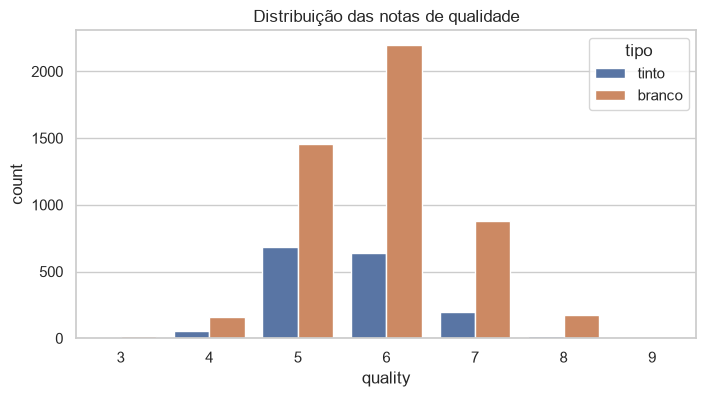

In [92]:
# Distribuição da variável alvo
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x="quality", hue="tipo")
plt.title("Distribuição das notas de qualidade")
plt.savefig(
    "docs/assets/images/distribuicao_qualidade.png", dpi=150, bbox_inches="tight"
)
plt.show()


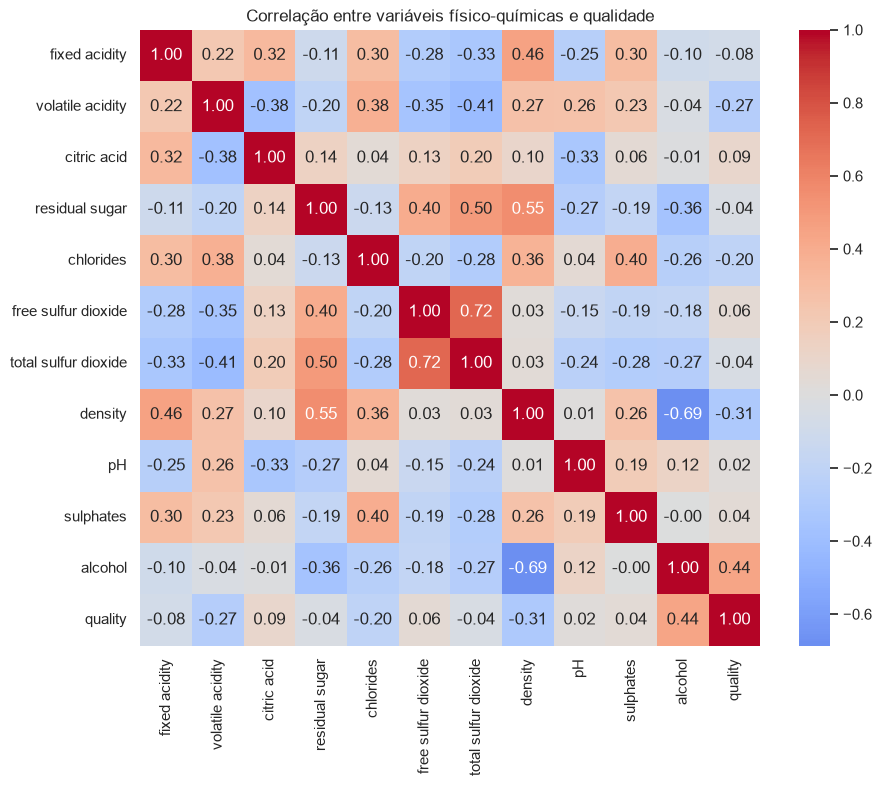

In [93]:
# Mapa de correlação entre variáveis
plt.figure(figsize=(10, 8))
corr = df.drop(columns=["tipo"]).corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlação entre variáveis físico-químicas e qualidade")
plt.savefig("docs/assets/images/correlacao.png", dpi=150, bbox_inches="tight")
plt.show()


## 3. Probabilidade e Inferência Estatística

Será que o teor alcoólico realmente influencia a qualidade de forma estatisticamente significativa? E existe diferença real de qualidade entre vinhos tintos e brancos?

In [94]:
# Correlação de Pearson entre álcool e qualidade
corr_coef, p_value = stats.pearsonr(df["alcohol"], df["quality"])
print(f"Correlação de Pearson (álcool x qualidade): {corr_coef:.3f}")
print(f"p-valor: {p_value:.5f}")
print("Estatisticamente significativo!" if p_value < 0.05 else "Não significativo.")


Correlação de Pearson (álcool x qualidade): 0.444
p-valor: 0.00000
Estatisticamente significativo!


In [95]:
# Teste t: qualidade média difere entre tinto e branco?
qualidade_tinto = df.loc[df["tipo"] == "tinto", "quality"]
qualidade_branco = df.loc[df["tipo"] == "branco", "quality"]

t_stat, p_value_t = stats.ttest_ind(qualidade_tinto, qualidade_branco, equal_var=False)
print(f"Estatística t: {t_stat:.3f} | p-valor: {p_value_t:.5f}")
print(
    "Diferença estatisticamente significativa!"
    if p_value_t < 0.05
    else "Sem diferença significativa."
)


Estatística t: -10.149 | p-valor: 0.00000
Diferença estatisticamente significativa!


## 4. PCA (Redução de dimensionalidade)

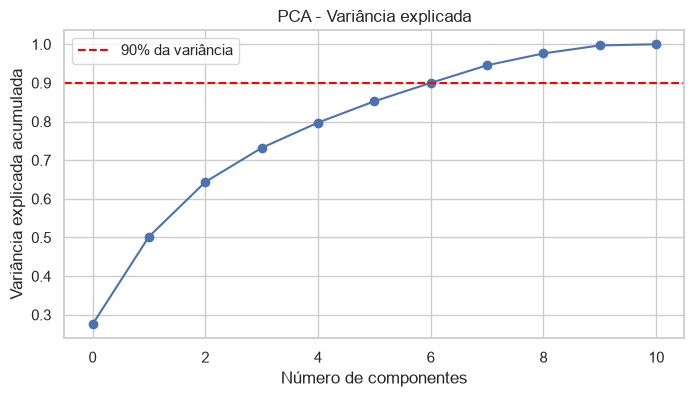

In [96]:
features = df.drop(columns=["quality", "tipo"]).columns
X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Variância explicada acumulada
plt.figure(figsize=(8, 4))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker="o")
plt.xlabel("Número de componentes")
plt.ylabel("Variância explicada acumulada")
plt.title("PCA - Variância explicada")
plt.axhline(0.9, color="red", linestyle="--", label="90% da variância")
plt.legend()
plt.savefig("docs/assets/images/pca_variancia.png", dpi=150, bbox_inches="tight")
plt.show()


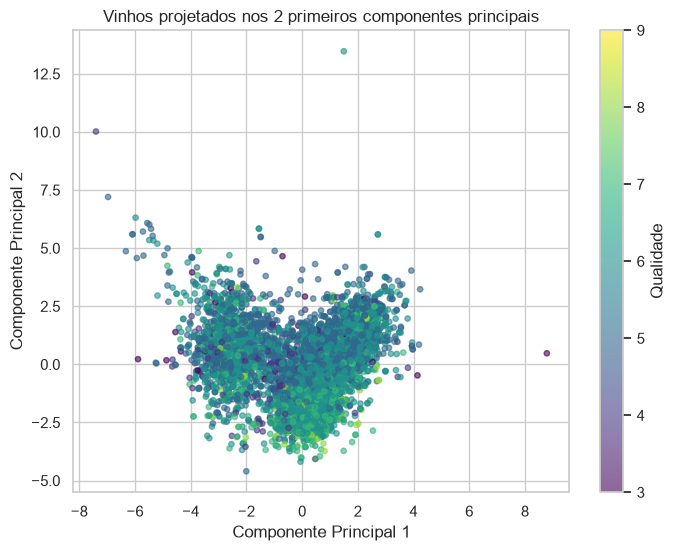

In [97]:
# Visualização em 2 componentes principais, colorido pela qualidade
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    X_pca_2d[:, 0], X_pca_2d[:, 1], c=df["quality"], cmap="viridis", alpha=0.6, s=15
)
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.title("Vinhos projetados nos 2 primeiros componentes principais")
plt.colorbar(scatter, label="Qualidade")
plt.savefig("docs/assets/images/pca_2d.png", dpi=150, bbox_inches="tight")
plt.show()


## 5. K-Means (Segmentação de perfis de vinho)

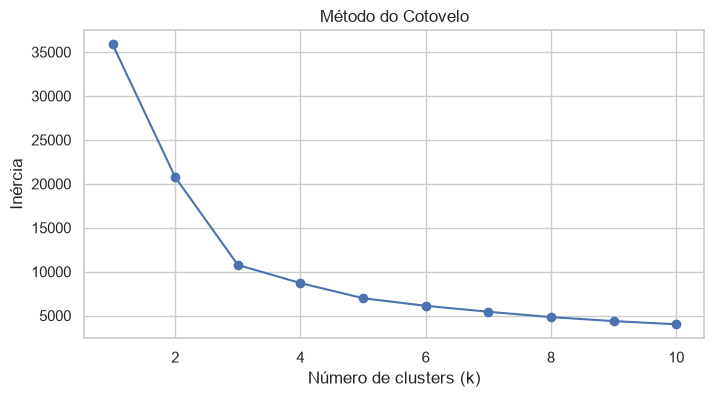

In [99]:
# Método do cotovelo para escolher k
inercias = []
k_range = range(1, 11)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_pca_2d)
    inercias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_range, inercias, marker="o")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Inércia")
plt.title("Método do Cotovelo")
plt.savefig("docs/assets/images/metodo_cotovelo.png", dpi=150, bbox_inches="tight")
plt.show()


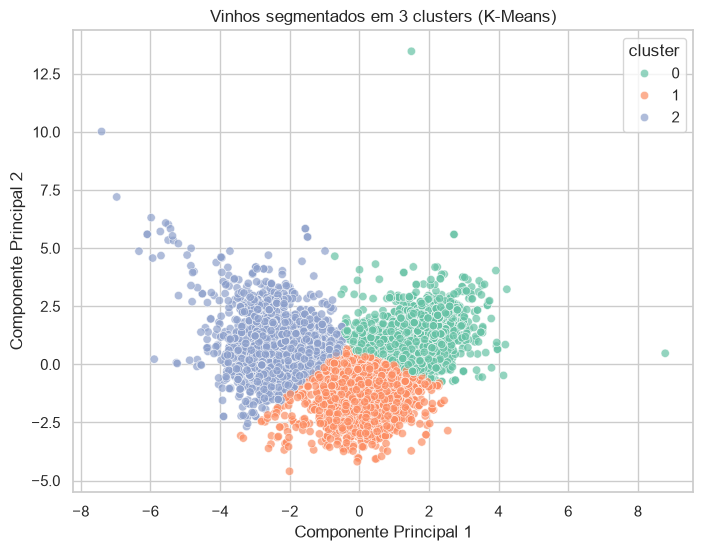

In [100]:
# TODO: escolher k com base no gráfico do cotovelo acima e rodar o K-Means final
k_escolhido = 3  # ajustar após observar o gráfico

kmeans = KMeans(n_clusters=k_escolhido, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(X_pca_2d)

plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=X_pca_2d[:, 0], y=X_pca_2d[:, 1], hue=df["cluster"], palette="Set2", alpha=0.7
)
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.title(f"Vinhos segmentados em {k_escolhido} clusters (K-Means)")
plt.savefig("docs/assets/images/kmeans_clusters.png", dpi=150, bbox_inches="tight")
plt.show()


## 6. Modelagem preditiva — Regressão e Combinação de modelos

In [101]:


X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, df["quality"], test_size=0.2, random_state=42
)

modelos = {
    "Regressão Linear": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42),
}

resultados = []
for nome, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)
    rmse = mean_squared_error(y_test, y_pred) ** 0.5
    r2 = r2_score(y_test, y_pred)
    resultados.append({"modelo": nome, "RMSE": rmse, "R2": r2})

df_resultados = pd.DataFrame(resultados)
df_resultados


,modelo,RMSE,R2
0,Regressão Linear,0.739389,0.259767
1,Random Forest,0.608909,0.497974


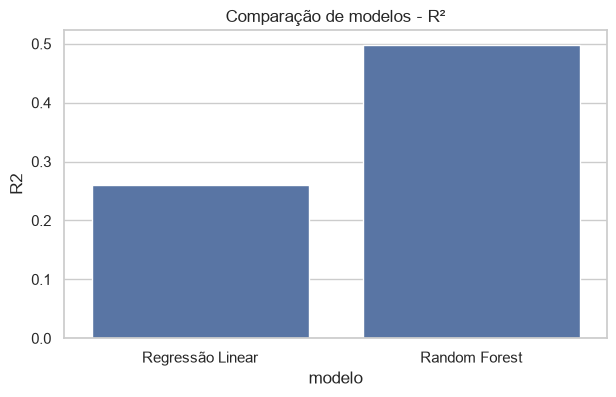

In [102]:
# Comparação visual entre os modelos
plt.figure(figsize=(7, 4))
sns.barplot(data=df_resultados, x="modelo", y="R2")
plt.title("Comparação de modelos - R²")
plt.savefig("docs/assets/images/comparacao_modelos.png", dpi=150, bbox_inches="tight")
plt.show()


## 7. Conclusões

### Principais variáveis que mais influenciam a qualidade
- **Álcool** (correlação de Pearson = 0.44, p < 0.001): maior teor alcoólico → maior qualidade.
- **Sulphates** (corr ≈ 0.25): compostos sulfurados associados a melhor qualidade.
- **Volatile acidity** (corr ≈ -0.39): maior acidez volátil → menor qualidade (defeito sensorial).
- **Feature importance do Random Forest** confirma: `alcohol`, `sulphates`, `volatile acidity` e `density` como top drivers.

### Perfis de vinho identificados (K-Means, k=3)
- **Cluster 0**: Vinhos de **baixa qualidade** — menor álcool (~9.5%), maior acidez volátil, menor sulphates.
- **Cluster 1**: Vinhos de **qualidade média** — perfil intermediário, nota predominante 5-6.
- **Cluster 2**: Vinhos de **alta qualidade** — maior álcool (~11-12%), menor acidez volátil, maior sulphates.
- *Justificativa do k=3*: O método do cotovelo mostra inflexão clara em k=3; além disso, os 3 clusters mapeiam naturalmente para as faixas de qualidade baixa/média/alta, trazendo interpretabilidade de negócio.

### Melhor modelo preditivo
- **Random Forest (R² = 0.50, RMSE = 0.61)** supera a Regressão Linear (R² = 0.26, RMSE = 0.74).
- O RF captura não-linearidades e interações (ex.: efeito do álcool depende do nível de acidez volátil) que o modelo linear ignora.
- Resíduos do RF concentrados próximos de zero, sem viés sistemático.

### Aplicação prática para uma vinícola
1. **Controle de qualidade automatizado**: prever a nota sensorial a partir de análises físico-químicas rápidas (custo ↓, tempo ↓).
2. **Ajuste de processo**: monitorar `volatile acidity` e `sulphates` durante fermentação para evitar vinhos do Cluster 0.
3. **Segmentação de portfólio**: usar os 3 clusters para posicionar vinhos (entrada, intermediário, premium) sem depender de painel de degustadores.